In [1]:
# =============================================================
# Seq2Seq Neural Machine Translation with Attention
#            English -> Urdu, built from scratch (no pretrained models)
# STEP 1: Parallel corpus + dual vocabularies
# =============================================================
#
# THE ARCHITECTURE WE'RE BUILDING:
#
#   English sentence
#        ↓  [Bi-LSTM Encoder]  reads forward AND backward
#   encoder states (one per input word)
#        ↓  [Bahdanau Attention]  decoder picks which to look at
#   context vector (changes at every output step)
#        ↓  [LSTM Decoder]  generates Urdu one word at a time
#   Urdu sentence
#
# WHY ATTENTION EXISTS AT ALL:
#   The original seq2seq squeezed the ENTIRE source sentence into
#   one fixed vector. For long sentences that's an information
#   bottleneck — the model forgets the beginning. Attention lets the
#   decoder look back at ALL encoder states at every output step and
#   weight them by relevance. It's the direct ancestor of the
#   self-attention you built in Project 1.
#
# FOUR SPECIAL TOKENS (generation needs more than classification):
#   <pad> = padding                       (id 0)
#   <sos> = start of sentence             (id 1)  <- decoder's first input
#   <eos> = end of sentence               (id 2)  <- how the model says "done"
#   <unk> = out-of-vocabulary             (id 3)
# =============================================================

!pip install datasets sacrebleu -q

# --- Colab compatibility patch (same torchvision issue as Projects 1 & 3) ---
import datasets.formatting.torch_formatter as _tf
_tf.config.TORCHVISION_AVAILABLE = False
# ----------------------------------------------------------------------------

import torch
import re
import random
from collections import Counter
from datasets import load_dataset

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------------------------------------------
# 1. Load the English-Urdu parallel corpus
# -------------------------------------------------------------
raw = load_dataset("Helsinki-NLP/opus-100", "en-ur")
print(raw)
print(raw["train"][0])
# Structure: {'translation': {'en': "...", 'ur': "..."}}

# -------------------------------------------------------------
# 2. Extract, clean, and filter the pairs
# -------------------------------------------------------------
MAX_LEN = 20          # max words per sentence (keeps training feasible)
MIN_LEN = 3
NUM_PAIRS = 120_000   # subsample — full corpus is too slow for free Colab

def clean_english(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s'.,!?]", " ", text)
    text = re.sub(r"([.,!?])", r" \1 ", text)     # separate punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_urdu(text):
    text = text.strip()
    # Keep Urdu/Arabic script block + Urdu punctuation, strip the rest
    text = re.sub(r"[^\u0600-\u06FF\u0750-\u077F\s۔،؟!]", " ", text)
    text = re.sub(r"([۔،؟!])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

pairs = []
for ex in raw["train"]:
    en = clean_english(ex["translation"]["en"])
    ur = clean_urdu(ex["translation"]["ur"])

    en_len, ur_len = len(en.split()), len(ur.split())
    if not (MIN_LEN <= en_len <= MAX_LEN):
        continue
    if not (MIN_LEN <= ur_len <= MAX_LEN):
        continue
    # Drop pairs with wildly mismatched lengths (usually bad alignments)
    if max(en_len, ur_len) / max(1, min(en_len, ur_len)) > 2.5:
        continue

    pairs.append((en, ur))
    if len(pairs) >= NUM_PAIRS:
        break

print(f"\nUsable pairs after filtering: {len(pairs):,}")
print("\nSample pairs:")
for en, ur in pairs[:5]:
    print(f"  EN: {en}")
    print(f"  UR: {ur}\n")

# -------------------------------------------------------------
# 3. Train / validation / test split
# -------------------------------------------------------------
random.shuffle(pairs)
n = len(pairs)
train_pairs = pairs[: int(0.90 * n)]
val_pairs   = pairs[int(0.90 * n) : int(0.95 * n)]
test_pairs  = pairs[int(0.95 * n) :]

print(f"Train: {len(train_pairs):,} | Val: {len(val_pairs):,} | Test: {len(test_pairs):,}")

# -------------------------------------------------------------
# 4. Build TWO separate vocabularies (source and target)
# -------------------------------------------------------------
# Translation needs two vocabs — English and Urdu share no words.
PAD, SOS, EOS, UNK = 0, 1, 2, 3
SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]

def build_vocab(sentences, max_size, min_freq=2):
    counter = Counter()
    for s in sentences:
        counter.update(s.split())

    word2id = {tok: i for i, tok in enumerate(SPECIALS)}
    for word, freq in counter.most_common(max_size - len(SPECIALS)):
        if freq < min_freq:
            break
        word2id[word] = len(word2id)

    id2word = {i: w for w, i in word2id.items()}
    return word2id, id2word, counter

SRC_VOCAB_SIZE = 15_000
TGT_VOCAB_SIZE = 15_000

# IMPORTANT: build from TRAIN only — never let val/test words leak in
src_w2i, src_i2w, src_counter = build_vocab([en for en, _ in train_pairs], SRC_VOCAB_SIZE)
tgt_w2i, tgt_i2w, tgt_counter = build_vocab([ur for _, ur in train_pairs], TGT_VOCAB_SIZE)

SRC_VOCAB = len(src_w2i)
TGT_VOCAB = len(tgt_w2i)
print(f"\nEnglish vocab: {SRC_VOCAB:,}")
print(f"Urdu vocab:    {TGT_VOCAB:,}")

# Coverage check: what fraction of tokens does the vocab actually cover?
def coverage(counter, w2i):
    total = sum(counter.values())
    covered = sum(c for w, c in counter.items() if w in w2i)
    return covered / total

print(f"English token coverage: {coverage(src_counter, src_w2i):.2%}")
print(f"Urdu token coverage:    {coverage(tgt_counter, tgt_w2i):.2%}")
# Below ~95% means too many <unk> — raise vocab size or lower min_freq.

# -------------------------------------------------------------
# 5. Encode sentences to ID tensors
# -------------------------------------------------------------
# Note the asymmetry:
#   SOURCE: just the words + <eos>
#   TARGET: <sos> + words + <eos>
# The decoder needs <sos> to have something to condition its first
# prediction on, and <eos> to learn when to stop generating.

def encode_src(sentence, w2i, max_len=MAX_LEN):
    ids = [w2i.get(w, UNK) for w in sentence.split()][: max_len - 1]
    ids = ids + [EOS]
    ids = ids + [PAD] * (max_len - len(ids))
    return ids

def encode_tgt(sentence, w2i, max_len=MAX_LEN):
    ids = [w2i.get(w, UNK) for w in sentence.split()][: max_len - 2]
    ids = [SOS] + ids + [EOS]
    ids = ids + [PAD] * (max_len - len(ids))
    return ids

def build_tensors(pair_list):
    src = torch.tensor([encode_src(en, src_w2i) for en, _ in pair_list], dtype=torch.long)
    tgt = torch.tensor([encode_tgt(ur, tgt_w2i) for _, ur in pair_list], dtype=torch.long)
    return src, tgt

train_src, train_tgt = build_tensors(train_pairs)
val_src,   val_tgt   = build_tensors(val_pairs)
test_src,  test_tgt  = build_tensors(test_pairs)

print(f"\ntrain_src: {train_src.shape}  train_tgt: {train_tgt.shape}")

# -------------------------------------------------------------
# 6. Verify the encoding round-trips correctly
# -------------------------------------------------------------
def decode_ids(ids, i2w, strip_specials=True):
    words = []
    for i in ids:
        i = int(i)
        if strip_specials and i in (PAD, SOS, EOS):
            continue
        words.append(i2w.get(i, "<unk>"))
    return " ".join(words)

print("\n--- Encoding round-trip check ---")
print("Original EN:", train_pairs[0][0])
print("Decoded  EN:", decode_ids(train_src[0], src_i2w))
print("Original UR:", train_pairs[0][1])
print("Decoded  UR:", decode_ids(train_tgt[0], tgt_i2w))
print("Raw target IDs (note <sos>=1 first, <eos>=2, then <pad>=0):")
print(train_tgt[0].tolist())

# -------------------------------------------------------------
# 7. DataLoaders
# -------------------------------------------------------------
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 128

train_loader = DataLoader(TensorDataset(train_src, train_tgt),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(TensorDataset(val_src, val_tgt),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_src, test_tgt),
                          batch_size=BATCH_SIZE, shuffle=False)

bx, by = next(iter(train_loader))
print(f"\nBatch src: {bx.shape}  Batch tgt: {by.shape}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.2 MB/s eta 0:00:00
Device: cuda


README.md:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

en-ur/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  301kB            

en-ur/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

en-ur/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  148MB            

...

en-ur/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/753913 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 753913
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})
{'translation': {'en': 'Yet, remember, as We communed with Moses for forty nights you took the calf in his absence (and worshipped it), and you did wrong.', 'ur': 'اورجب ہم نے موسیٰ سے چالیس رات کا وعدہ کیا پھر اس کے بعد تم نے بچھڑا بنا لیا حالانکہ تم ظالم تھے'}}

Usable pairs after filtering: 120,000

Sample pairs:
  EN: except , among them , your chosen servants .
  UR: بجز تیرے اُن بندوں کے جنہیں تو نے خالص کر لیا ہے

  EN: soon we shall brand him on his snout .
  UR: ہم عنقریب اس کی ناک پر داغ لگائیں گے

  EN: and most of them are such that they do not believe in allah except while ascribing partners to him !
  UR: اور ان میںکی اکثریت خدا پر ایمان بھی لاتی ہے تو شرک کے ساتھ

  EN: reclining on them , array

In [2]:
# =============================================================
# STEP 2: The architecture
#   Bi-LSTM Encoder + Bahdanau (additive) Attention + LSTM Decoder
# =============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import random

# =============================================================
# 2.1 — ENCODER
# =============================================================
# BIDIRECTIONAL, because context flows both ways in a sentence.
# Reading "bank" you need the words after it as much as before it.
#
#   forward  LSTM: → → → → →   sees left context
#   backward LSTM: ← ← ← ← ←   sees right context
#   concatenate   : each position now encodes the FULL sentence
#
# Shapes:
#   input          (B, S)
#   embedded       (B, S, E)
#   outputs        (B, S, 2H)   <- 2H because bidirectional
#   final hidden   (2, B, H)    <- one per direction; must be merged
#                                   into (1, B, H) for the decoder
# =============================================================

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True,
                            bidirectional=True)
        # Merge the two directions down to the decoder's hidden size
        self.fc_hidden = nn.Linear(hid_dim * 2, hid_dim)
        self.fc_cell   = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (B, S)
        embedded = self.dropout(self.embedding(src))        # (B, S, E)
        outputs, (hidden, cell) = self.lstm(embedded)
        # outputs: (B, S, 2H)   hidden/cell: (2, B, H)

        # Concatenate forward [0] and backward [1] final states, project to H
        hidden = torch.tanh(self.fc_hidden(
            torch.cat((hidden[0], hidden[1]), dim=1)))       # (B, H)
        cell = torch.tanh(self.fc_cell(
            torch.cat((cell[0], cell[1]), dim=1)))           # (B, H)

        # Decoder LSTM expects (num_layers, B, H)
        return outputs, hidden.unsqueeze(0), cell.unsqueeze(0)


# =============================================================
# 2.2 — BAHDANAU (ADDITIVE) ATTENTION
# =============================================================
# THE FORMULA:
#   energy_i = vᵀ · tanh( W1·encoder_output_i + W2·decoder_hidden )
#   α        = softmax(energy)                  <- attention weights
#   context  = Σ αᵢ · encoder_output_i          <- weighted sum
#
# CONTRAST WITH PROJECT 1:
#   Project 1 used MULTIPLICATIVE attention: softmax(QKᵀ/√d)·V
#     - a dot product, no learned parameters in the scoring itself
#   This uses ADDITIVE attention: a small feedforward net scores
#     - more parameters, but works well when Q and K have
#       different dimensions (here: H vs 2H)
#   Both answer the same question: "which source positions matter
#   for what I'm generating right now?"
#
# THE MASK is essential: without it the decoder can attend to <pad>
# positions, which carry no information and corrupt the context vector.
# =============================================================

class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W1 = nn.Linear(hid_dim * 2, hid_dim, bias=False)  # over encoder outputs
        self.W2 = nn.Linear(hid_dim, hid_dim, bias=False)      # over decoder hidden
        self.v  = nn.Linear(hid_dim, 1, bias=False)            # scores to scalar

    def forward(self, decoder_hidden, encoder_outputs, mask):
        # decoder_hidden:  (B, H)
        # encoder_outputs: (B, S, 2H)
        # mask:            (B, S)  True = real token, False = pad

        # Broadcast decoder hidden across all source positions
        dec = self.W2(decoder_hidden).unsqueeze(1)      # (B, 1, H)
        enc = self.W1(encoder_outputs)                  # (B, S, H)

        energy = torch.tanh(enc + dec)                  # (B, S, H)
        scores = self.v(energy).squeeze(2)              # (B, S)

        # Kill attention to padding BEFORE softmax
        scores = scores.masked_fill(~mask, float("-inf"))

        attn_weights = F.softmax(scores, dim=1)         # (B, S)

        # Weighted sum of encoder outputs = the context vector
        context = torch.bmm(attn_weights.unsqueeze(1),  # (B, 1, S)
                            encoder_outputs)            # (B, S, 2H)
        context = context.squeeze(1)                    # (B, 2H)

        return context, attn_weights


# =============================================================
# 2.3 — DECODER (one step at a time)
# =============================================================
# The decoder runs ONE token per call. Its LSTM input is the
# concatenation of:
#   - the embedding of the previously generated token
#   - the context vector from attention (recomputed every step)
#
# That second part is the whole point: the context CHANGES at every
# output step, because what the decoder needs to look at changes as
# it moves through the target sentence.
#
# The final projection sees [lstm_output ; context ; embedding] —
# giving the classifier direct access to all three signals rather
# than forcing everything through the LSTM state.
# =============================================================

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, attention, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim + hid_dim * 2, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim + hid_dim * 2 + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs, mask):
        # input_token: (B,)  a single token id per batch item
        input_token = input_token.unsqueeze(1)                    # (B, 1)
        embedded = self.dropout(self.embedding(input_token))      # (B, 1, E)

        # Attention uses the CURRENT decoder state
        context, attn_weights = self.attention(
            hidden.squeeze(0), encoder_outputs, mask)             # (B, 2H), (B, S)

        lstm_input = torch.cat((embedded, context.unsqueeze(1)), dim=2)
        # (B, 1, E + 2H)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        # output: (B, 1, H)

        prediction = self.fc_out(torch.cat(
            (output.squeeze(1), context, embedded.squeeze(1)), dim=1))
        # (B, vocab_size)

        return prediction, hidden, cell, attn_weights


# =============================================================
# 2.4 — SEQ2SEQ WRAPPER (with teacher forcing)
# =============================================================
# TEACHER FORCING — the key training trick:
#
#   Without it: feed the model's OWN prediction back as next input.
#     Problem: early in training every prediction is garbage, so the
#     model trains on garbage inputs and never converges.
#
#   With it: feed the GROUND TRUTH previous word instead.
#     Trains fast and stably.
#
#   The catch (exposure bias): at inference there IS no ground truth,
#   so the model faces inputs it never saw in training. The standard
#   compromise is a teacher-forcing RATIO — use ground truth ~50% of
#   the time, the model's own prediction the rest — so it learns to
#   recover from its own mistakes.
# =============================================================

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx=0, sos_idx=1, eos_idx=2):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx
        self.sos_idx = sos_idx
        self.eos_idx = eos_idx

    def make_mask(self, src):
        return src != self.pad_idx          # (B, S) True where real token

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src: (B, S_src)   tgt: (B, S_tgt)
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.vocab_size

        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src.device)

        encoder_outputs, hidden, cell = self.encoder(src)
        mask = self.make_mask(src)

        # First decoder input is always <sos>
        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            prediction, hidden, cell, _ = self.decoder(
                input_token, hidden, cell, encoder_outputs, mask)
            outputs[:, t] = prediction

            use_teacher = random.random() < teacher_forcing_ratio
            top1 = prediction.argmax(1)
            input_token = tgt[:, t] if use_teacher else top1

        return outputs


# =============================================================
# 2.5 — INSTANTIATE AND SANITY-CHECK
# =============================================================
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3

attention = BahdanauAttention(HID_DIM)
encoder   = Encoder(SRC_VOCAB, EMB_DIM, HID_DIM, DROPOUT)
decoder   = Decoder(TGT_VOCAB, EMB_DIM, HID_DIM, attention, DROPOUT)
model     = Seq2Seq(encoder, decoder).to(device)

# Weight init — uniform in [-0.08, 0.08] is the standard seq2seq recipe
def init_weights(m):
    for name, param in m.named_parameters():
        if "weight" in name and param.dim() > 1:
            nn.init.uniform_(param, -0.08, 0.08)
        elif "bias" in name:
            nn.init.zeros_(param)

model.apply(init_weights)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
enc_params = sum(p.numel() for p in encoder.parameters())
dec_params = sum(p.numel() for p in decoder.parameters())
print(f"Encoder parameters: {enc_params:,}")
print(f"Decoder parameters: {dec_params:,}")
print(f"Total trainable:    {total_params:,}")

# Shape check on one real batch
sample_src, sample_tgt = next(iter(train_loader))
sample_src, sample_tgt = sample_src.to(device), sample_tgt.to(device)
with torch.no_grad():
    out = model(sample_src, sample_tgt, teacher_forcing_ratio=0.5)
print(f"\nModel output shape: {out.shape}")
print(f"Expected:           ({sample_src.size(0)}, {sample_tgt.size(1)}, {TGT_VOCAB})")

Encoder parameters: 7,166,464
Decoder parameters: 26,397,650
Total trainable:    33,564,114

Model output shape: torch.Size([128, 20, 10706])
Expected:           (128, 20, 10706)


In [3]:
# =============================================================
# STEP 3: Training
# =============================================================
# =============================================================

import torch
import torch.nn as nn
import time
import math

# -------------------------------------------------------------
# 1. Loss and optimizer
# -------------------------------------------------------------
criterion = nn.CrossEntropyLoss(ignore_index=PAD)   # <- the masking
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

CLIP = 1.0
EPOCHS = 10

# -------------------------------------------------------------
# 2. Train / evaluate one epoch
# -------------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, clip, tf_ratio):
    model.train()
    epoch_loss = 0

    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=tf_ratio)
        # output: (B, T, V)   tgt: (B, T)

        # Drop position 0 (<sos>) — the model never predicts it
        output = output[:, 1:].reshape(-1, output.size(-1))   # (B*(T-1), V)
        target = tgt[:, 1:].reshape(-1)                       # (B*(T-1),)

        loss = criterion(output, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            # teacher_forcing_ratio=0 — evaluate the way inference runs
            output = model(src, tgt, teacher_forcing_ratio=0.0)

            output = output[:, 1:].reshape(-1, output.size(-1))
            target = tgt[:, 1:].reshape(-1)
            epoch_loss += criterion(output, target).item()

    return epoch_loss / len(loader)


def epoch_time(start, end):
    elapsed = end - start
    return int(elapsed // 60), int(elapsed % 60)

# -------------------------------------------------------------
# 3. Training loop with teacher-forcing decay
# -------------------------------------------------------------
# We START at high teacher forcing (fast, stable early learning) and
# DECAY it, so the model progressively learns to handle its own
# imperfect predictions — narrowing the train/inference gap.

train_losses, val_losses, tf_ratios = [], [], []
best_val_loss = float("inf")

print(f"Training on {device} for {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    tf_ratio = max(0.5, 1.0 - (epoch * 0.06))   # 1.0 -> 0.5 over training
    tf_ratios.append(tf_ratio)

    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP, tf_ratio)
    val_loss   = evaluate_epoch(model, val_loader, criterion)
    end = time.time()

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    mins, secs = epoch_time(start, end)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "nmt_best.pt")
        marker = "  <- saved"
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d} | {mins}m {secs}s | tf={tf_ratio:.2f}")
    print(f"   train loss {train_loss:.3f} | train PPL {math.exp(train_loss):7.2f}")
    print(f"   val   loss {val_loss:.3f} | val   PPL {math.exp(val_loss):7.2f}{marker}")

# -------------------------------------------------------------
# 4. Load the best checkpoint and report test perplexity
# -------------------------------------------------------------
model.load_state_dict(torch.load("nmt_best.pt"))

test_loss = evaluate_epoch(model, test_loader, criterion)
test_ppl = math.exp(test_loss)

print(f"\n{'='*50}")
print(f"Test loss:       {test_loss:.3f}")
print(f"Test perplexity: {test_ppl:.2f}")
print(f"{'='*50}")


Training on cuda for 10 epochs

Epoch  1 | 3m 22s | tf=1.00
   train loss 3.715 | train PPL   41.05
   val   loss 5.508 | val   PPL  246.58  <- saved
Epoch  2 | 3m 42s | tf=0.94
   train loss 2.060 | train PPL    7.85
   val   loss 5.080 | val   PPL  160.79  <- saved
Epoch  3 | 3m 47s | tf=0.88
   train loss 1.587 | train PPL    4.89
   val   loss 4.933 | val   PPL  138.76  <- saved
Epoch  4 | 3m 46s | tf=0.82
   train loss 1.365 | train PPL    3.92
   val   loss 4.912 | val   PPL  135.96  <- saved
Epoch  5 | 3m 46s | tf=0.76
   train loss 1.255 | train PPL    3.51
   val   loss 4.851 | val   PPL  127.81  <- saved
Epoch  6 | 3m 47s | tf=0.70
   train loss 1.208 | train PPL    3.35
   val   loss 4.774 | val   PPL  118.45  <- saved
Epoch  7 | 3m 47s | tf=0.64
   train loss 1.181 | train PPL    3.26
   val   loss 4.680 | val   PPL  107.77  <- saved
Epoch  8 | 3m 47s | tf=0.58
   train loss 1.242 | train PPL    3.46
   val   loss 4.484 | val   PPL   88.60  <- saved
Epoch  9 | 3m 46s | tf=0

In [4]:
# =============================================================
# STEP 4: Inference — Greedy vs Beam Search
# =============================================================
# TRAINING vs INFERENCE, the fundamental asymmetry:
#
#   Training:  the full target sentence exists. Teacher forcing
#              feeds ground truth. Everything is parallelizable.
#   Inference: NOTHING exists. The model starts from <sos> and
#              generates one token at a time, feeding each output
#              back as the next input, until it emits <eos>.
#
# GREEDY DECODING: take argmax at every step.
#   Fast, but myopic. One bad early choice poisons everything after
#   it, and greedy can never take it back.
#
# BEAM SEARCH: keep the k best partial sequences at every step.
#   At each step, expand all k beams, score all candidates by TOTAL
#   sequence log-probability, keep the best k. A locally-worse token
#   survives if it leads somewhere better.
#
#   LENGTH NORMALIZATION matters: log-probs are negative and sum, so
#   longer sequences always score worse. Without dividing by length,
#   beam search systematically prefers short, truncated translations.
# =============================================================

import torch
import torch.nn.functional as F

# -------------------------------------------------------------
# 1. GREEDY DECODING
# -------------------------------------------------------------
def translate_greedy(model, sentence, src_w2i, tgt_i2w,
                     max_len=MAX_LEN, device=device, return_attention=False):
    model.eval()

    # Clean and encode exactly as in training
    if isinstance(sentence, str):
        cleaned = clean_english(sentence)
        src_ids = encode_src(cleaned, src_w2i, max_len)
    else:
        src_ids = sentence

    src = torch.tensor([src_ids], dtype=torch.long, device=device)   # (1, S)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)
        mask = model.make_mask(src)

        input_token = torch.tensor([SOS], device=device)
        result_ids, attentions = [], []

        for _ in range(max_len):
            prediction, hidden, cell, attn = model.decoder(
                input_token, hidden, cell, encoder_outputs, mask)

            attentions.append(attn.squeeze(0).cpu())
            top1 = prediction.argmax(1)

            if top1.item() == EOS:
                break

            result_ids.append(top1.item())
            input_token = top1          # <- feed own prediction back

    translation = " ".join(tgt_i2w.get(i, "<unk>") for i in result_ids)

    if return_attention:
        attn_matrix = torch.stack(attentions) if attentions else torch.empty(0)
        return translation, attn_matrix
    return translation


# -------------------------------------------------------------
# 2. BEAM SEARCH DECODING
# -------------------------------------------------------------
def translate_beam(model, sentence, src_w2i, tgt_i2w,
                   beam_width=5, max_len=MAX_LEN,
                   length_penalty=0.7, device=device):
    model.eval()

    if isinstance(sentence, str):
        cleaned = clean_english(sentence)
        src_ids = encode_src(cleaned, src_w2i, max_len)
    else:
        src_ids = sentence

    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)
        mask = model.make_mask(src)

        # Each beam: (token_ids, cumulative_logprob, hidden, cell)
        beams = [([SOS], 0.0, hidden, cell)]
        completed = []

        for _ in range(max_len):
            candidates = []

            for tokens, score, h, c in beams:
                # Already finished — move to completed, don't expand
                if tokens[-1] == EOS:
                    completed.append((tokens, score, h, c))
                    continue

                input_token = torch.tensor([tokens[-1]], device=device)
                prediction, new_h, new_c, _ = model.decoder(
                    input_token, h, c, encoder_outputs, mask)

                log_probs = F.log_softmax(prediction, dim=1)       # (1, V)
                topk_lp, topk_ids = log_probs.topk(beam_width, dim=1)

                for k in range(beam_width):
                    tok = topk_ids[0, k].item()
                    lp  = topk_lp[0, k].item()
                    candidates.append((tokens + [tok], score + lp, new_h, new_c))

            if not candidates:
                break

            # Keep the best `beam_width` candidates, normalized by length
            candidates.sort(
                key=lambda x: x[1] / (len(x[0]) ** length_penalty),
                reverse=True,
            )
            beams = candidates[:beam_width]

            # Stop once every surviving beam has finished
            if all(b[0][-1] == EOS for b in beams):
                completed.extend(beams)
                break

        if not completed:
            completed = beams

        completed.sort(key=lambda x: x[1] / (len(x[0]) ** length_penalty),
                       reverse=True)
        best_tokens = completed[0][0]

    words = [tgt_i2w.get(i, "<unk>") for i in best_tokens
             if i not in (SOS, EOS, PAD)]
    return " ".join(words)


# -------------------------------------------------------------
# 3. Compare the two side by side on real test sentences
# -------------------------------------------------------------
print("=" * 70)
print("GREEDY vs BEAM SEARCH")
print("=" * 70)

for i in range(8):
    en_src, ur_ref = test_pairs[i]

    greedy = translate_greedy(model, en_src, src_w2i, tgt_i2w)
    beam   = translate_beam(model, en_src, src_w2i, tgt_i2w, beam_width=5)

    print(f"\nSOURCE (EN) : {en_src}")
    print(f"REFERENCE   : {ur_ref}")
    print(f"GREEDY      : {greedy}")
    print(f"BEAM (k=5)  : {beam}")

# -------------------------------------------------------------
# 4. Try your own sentences
# -------------------------------------------------------------
custom_sentences = [
    "i am going to school today",
    "the weather is very nice",
    "he is a good student",
    "we will meet tomorrow morning",
    "this book is very interesting",
]

print("\n" + "=" * 70)
print("CUSTOM SENTENCES")
print("=" * 70)
for s in custom_sentences:
    print(f"\nEN   : {s}")
    print(f"UR   : {translate_beam(model, s, src_w2i, tgt_i2w, beam_width=5)}")

# -------------------------------------------------------------
# 5. Effect of beam width (a good ablation for the README)
# -------------------------------------------------------------
sample_sentence = test_pairs[0][0]
print("\n" + "=" * 70)
print(f"BEAM WIDTH ABLATION  —  source: {sample_sentence}")
print(f"reference: {test_pairs[0][1]}")
print("=" * 70)
for k in [1, 3, 5, 10]:
    out = translate_beam(model, sample_sentence, src_w2i, tgt_i2w, beam_width=k)
    print(f"  k={k:2d}: {out}")

GREEDY vs BEAM SEARCH

SOURCE (EN) : woe to the deniers on that day !
REFERENCE   : اس دن جھٹلانے والوں کے لئے بڑی تباہی ہے ،
GREEDY      : اس دن جھٹلانے والوں کے لئے بڑی خرابی ہے ،
BEAM (k=5)  : اس دن جھٹلانے والوں کے لئے بڑی خرابی ہے ،

SOURCE (EN) : and we admitted him into our mercy indeed he is among those who deserve our proximity .
REFERENCE   : اور لوطؑ کو ہم نے اپنی رحمت میں داخل کیا ، وہ صالح لوگوں میں سے تھا
GREEDY      : اور لوطؑ نے اپنی رحمت میں داخل کیا ۔ وہ ہمارے نیک کردار بندوں میں سے
BEAM (k=5)  : اور لوطؑ کو ہم نے اپنی رحمت میں داخل کیا ، وہ یقینا ہمارے نیک کردار بندوں میں

SOURCE (EN) : and we gave him out of our mercy his brother aaron as a prophet .
REFERENCE   : اور ہم نے اسے اپنی رحمت سے ان کے بھائی ہارون کو نبی بنا کر عطا کیا
GREEDY      : اور اپنی مہربانی سے اس کا بھائی ہارون عطا کیا غیب کی خبریں بتانے والا نبی
BEAM (k=5)  : اور اپنی مہربانی سے اُن کو اُن کا بھائی ہارون پیغمبر عطا کیا

SOURCE (EN) : thank you .
REFERENCE   : انہوں نے یہ کیا
GREEDY      : آپ کا 

Computing BLEU (greedy)...
Computing BLEU (beam k=5)...

BLEU (greedy)   : 23.81   [14.6s]
BLEU (beam k=5) : 23.96   [101.2s]
Beam is 6.9x slower for +0.15 BLEU

Greedy detail: BLEU = 23.81 51.1/28.4/17.9/12.4 (BP = 0.999 ratio = 0.999 hyp_len = 11543 ref_len = 11552)
Beam detail:   BLEU = 23.96 50.7/28.1/18.3/13.0 (BP = 0.994 ratio = 0.994 hyp_len = 11483 ref_len = 11552)
  beam k=1: BLEU 22.53  (4.7s)
  beam k=3: BLEU 21.89  (16.9s)
  beam k=5: BLEU 22.94  (29.8s)
  beam k=8: BLEU 22.77  (51.7s)


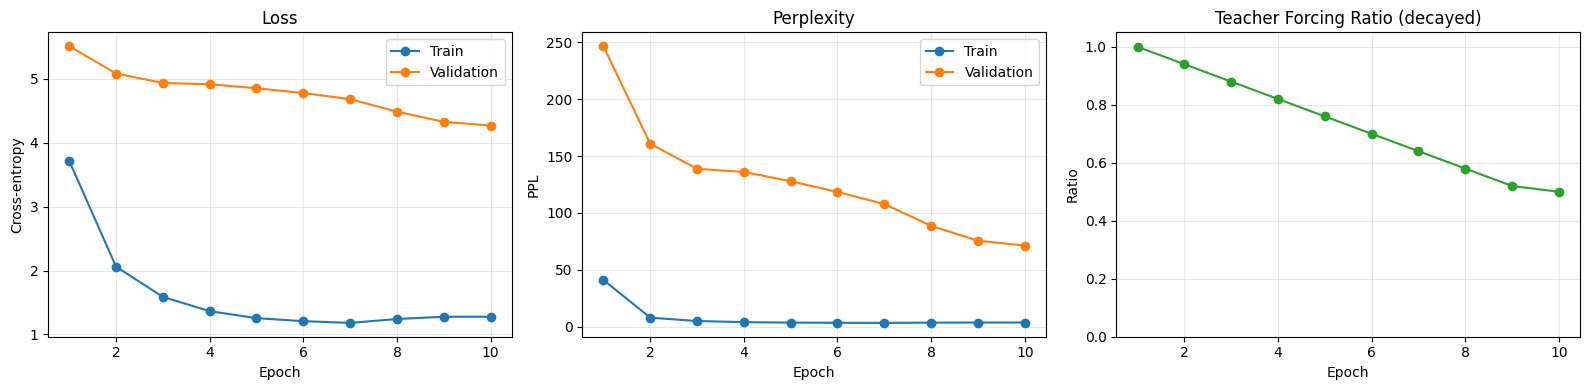

Saved nmt_training_curves.png


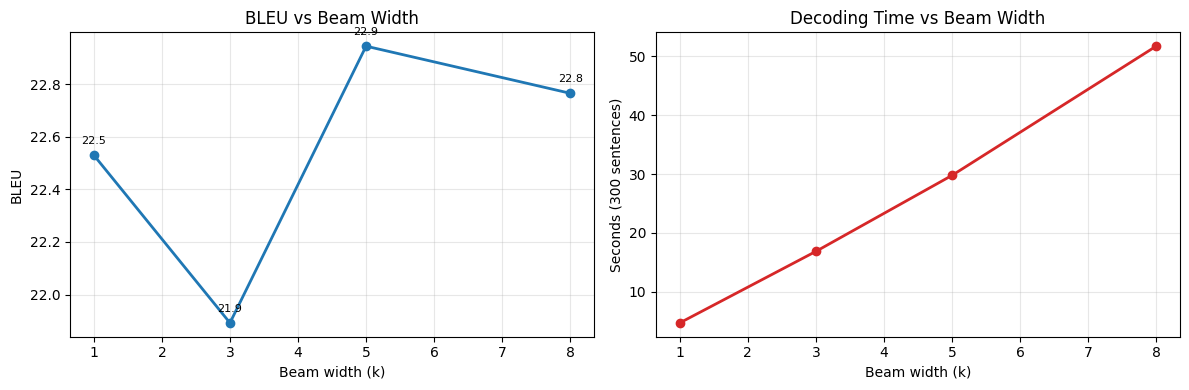

Saved nmt_beam_ablation.png


/tmp/ipykernel_1325/4249485281.py:189: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_1325/4249485281.py:189: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_1325/4249485281.py:192: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.savefig(filename, dpi=150, bbox_inches="tight")
/tmp/ipykernel_1325/4249485281.py:192: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.savefig(filename, dpi=150, bbox_inches="tight")


Saved nmt_attention_1.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)


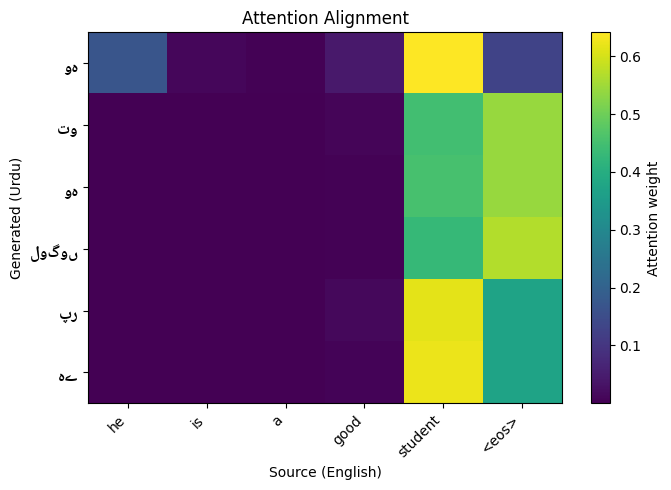


SOURCE     : he is a good student
TRANSLATION: وہ تو وہ لوگوں پر ہے


/tmp/ipykernel_1325/4249485281.py:189: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_1325/4249485281.py:189: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_1325/4249485281.py:192: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.savefig(filename, dpi=150, bbox_inches="tight")
/tmp/ipykernel_1325/4249485281.py:192: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.savefig(filename, dpi=150, bbox_inches="tight")


Saved nmt_attention_2.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)


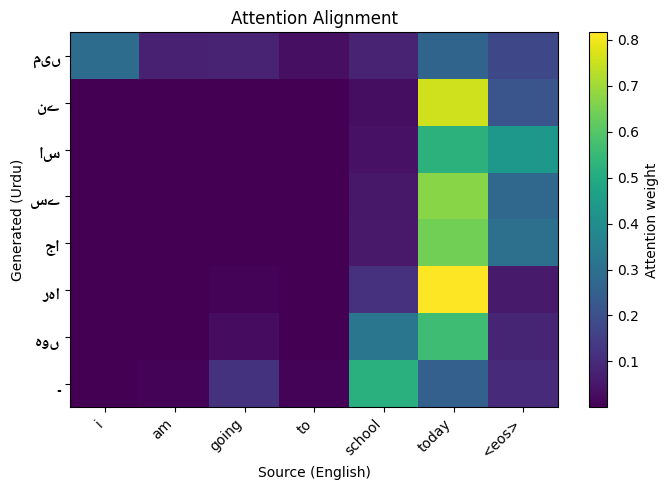


SOURCE     : i am going to school today
TRANSLATION: میں نے اس سے جا رہا ہوں ۔


/tmp/ipykernel_1325/4249485281.py:189: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_1325/4249485281.py:189: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipykernel_1325/4249485281.py:192: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.savefig(filename, dpi=150, bbox_inches="tight")
/tmp/ipykernel_1325/4249485281.py:192: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.savefig(filename, dpi=150, bbox_inches="tight")


Saved nmt_attention_3.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)


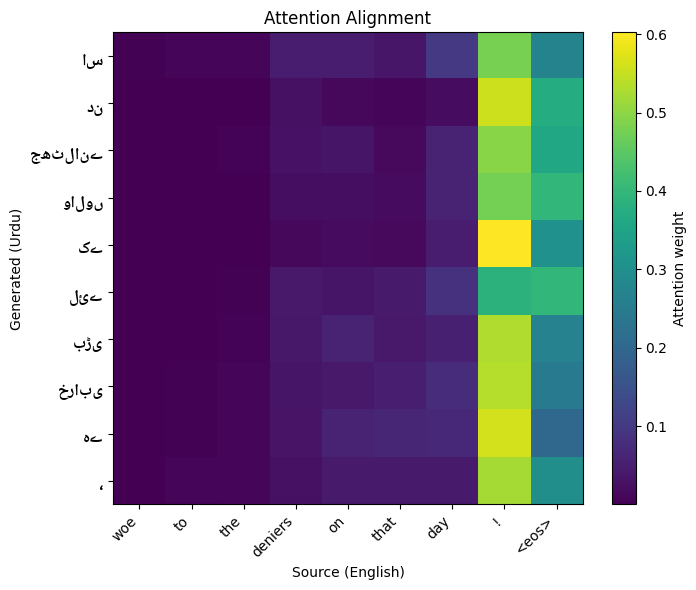


SOURCE     : woe to the deniers on that day !
TRANSLATION: اس دن جھٹلانے والوں کے لئے بڑی خرابی ہے ،

SAMPLE TRANSLATIONS (test set)

[1] BLEU 70.7
  EN  : woe to the deniers on that day !
  REF : اس دن جھٹلانے والوں کے لئے بڑی تباہی ہے ،
  HYP : اس دن جھٹلانے والوں کے لئے بڑی خرابی ہے ،

[2] BLEU 64.7
  EN  : and we admitted him into our mercy indeed he is among those who deserve our proximity .
  REF : اور لوطؑ کو ہم نے اپنی رحمت میں داخل کیا ، وہ صالح لوگوں میں سے تھا
  HYP : اور لوطؑ کو ہم نے اپنی رحمت میں داخل کیا ، وہ یقینا ہمارے نیک کردار بندوں میں

[3] BLEU 7.6
  EN  : and we gave him out of our mercy his brother aaron as a prophet .
  REF : اور ہم نے اسے اپنی رحمت سے ان کے بھائی ہارون کو نبی بنا کر عطا کیا
  HYP : اور اپنی مہربانی سے اُن کو اُن کا بھائی ہارون پیغمبر عطا کیا

[4] BLEU 0.0
  EN  : thank you .
  REF : انہوں نے یہ کیا
  HYP : آپ کا شکریہ

[5] BLEU 9.3
  EN  : a day wherein mankind will be as thickly scattered moths
  REF : وہ قیامت ہے جس دن لوگ ایسے ہوں گے جیسے ب

In [5]:
# =============================================================
# STEP 5: Evaluation + Visualization
# =============================================================
# BLEU is the standard translation metric. It compares n-gram
# overlap (1- through 4-grams) between the hypothesis and the
# reference, with a brevity penalty so the model can't game it by
# producing very short outputs.
#
# BLEU is IMPERFECT — a perfectly good paraphrase scores badly
# because it uses different words. But it's comparable across
# systems, which is what makes it the field standard.
#
# CALIBRATION for a from-scratch model on ~120K pairs:
#   BLEU  <5   : mostly broken
#   BLEU  5-10 : recognizable structure, many errors
#   BLEU 10-20 : usable-ish for short simple sentences
#   BLEU 20+   : good for this setup
# Pretrained NMT systems score far higher — they train on tens of
# millions of pairs. The point here is the architecture, not SOTA.
# =============================================================

!pip install sacrebleu -q

import sacrebleu
import matplotlib.pyplot as plt
import numpy as np
import math
import time

# -------------------------------------------------------------
# 1. BLEU on the test set — greedy vs beam
# -------------------------------------------------------------
def compute_bleu(model, pairs, decode_fn, n_samples=1000, **kwargs):
    hypotheses, references = [], []

    subset = pairs[:n_samples]
    start = time.time()
    for en_src, ur_ref in subset:
        hyp = decode_fn(model, en_src, src_w2i, tgt_i2w, **kwargs)
        hypotheses.append(hyp)
        references.append(ur_ref)
    elapsed = time.time() - start

    # sacrebleu expects references as a list of reference-lists
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    return bleu, hypotheses, references, elapsed

print("Computing BLEU (greedy)...")
bleu_greedy, hyp_g, refs, time_g = compute_bleu(
    model, test_pairs, translate_greedy, n_samples=1000)

print("Computing BLEU (beam k=5)...")
bleu_beam, hyp_b, _, time_b = compute_bleu(
    model, test_pairs, translate_beam, n_samples=1000, beam_width=5)

print("\n" + "=" * 55)
print(f"BLEU (greedy)   : {bleu_greedy.score:.2f}   [{time_g:.1f}s]")
print(f"BLEU (beam k=5) : {bleu_beam.score:.2f}   [{time_b:.1f}s]")
print(f"Beam is {time_b/max(time_g,1e-9):.1f}x slower for "
      f"{bleu_beam.score - bleu_greedy.score:+.2f} BLEU")
print("=" * 55)
print(f"\nGreedy detail: {bleu_greedy}")
print(f"Beam detail:   {bleu_beam}")

# -------------------------------------------------------------
# 2. BLEU vs beam width (the ablation chart)
# -------------------------------------------------------------
beam_widths = [1, 3, 5, 8]
beam_scores, beam_times = [], []

for k in beam_widths:
    b, _, _, t = compute_bleu(model, test_pairs, translate_beam,
                              n_samples=300, beam_width=k)
    beam_scores.append(b.score)
    beam_times.append(t)
    print(f"  beam k={k}: BLEU {b.score:.2f}  ({t:.1f}s)")

# -------------------------------------------------------------
# 3. Training curves + perplexity
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_x = range(1, len(train_losses) + 1)

axes[0].plot(epochs_x, train_losses, marker="o", label="Train")
axes[0].plot(epochs_x, val_losses,   marker="o", label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, [math.exp(l) for l in train_losses], marker="o", label="Train")
axes[1].plot(epochs_x, [math.exp(l) for l in val_losses],   marker="o", label="Validation")
axes[1].set_title("Perplexity")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PPL")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_x, tf_ratios, marker="o", color="tab:green")
axes[2].set_title("Teacher Forcing Ratio (decayed)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Ratio")
axes[2].set_ylim(0, 1.05); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nmt_training_curves.png", dpi=150)
plt.show()
print("Saved nmt_training_curves.png")

# -------------------------------------------------------------
# 4. BLEU vs beam width chart
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(beam_widths, beam_scores, marker="o", color="tab:blue", linewidth=2)
axes[0].set_title("BLEU vs Beam Width")
axes[0].set_xlabel("Beam width (k)"); axes[0].set_ylabel("BLEU")
axes[0].grid(alpha=0.3)
for k, s in zip(beam_widths, beam_scores):
    axes[0].annotate(f"{s:.1f}", (k, s), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)

axes[1].plot(beam_widths, beam_times, marker="o", color="tab:red", linewidth=2)
axes[1].set_title("Decoding Time vs Beam Width")
axes[1].set_xlabel("Beam width (k)"); axes[1].set_ylabel("Seconds (300 sentences)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nmt_beam_ablation.png", dpi=150)
plt.show()
print("Saved nmt_beam_ablation.png")

# -------------------------------------------------------------
# 5. ATTENTION ALIGNMENT HEATMAP — the signature visual
# -------------------------------------------------------------
# This is the most interesting output of the whole project. Each row
# is one generated Urdu word; each column is one English source word.
# Bright cells = the decoder was looking there when it produced that
# word. A well-trained model shows a rough diagonal (word alignment),
# with off-diagonal jumps where the languages reorder — and English
# and Urdu reorder a LOT, since Urdu is subject-object-VERB.
#
# NOTE ON URDU RENDERING: matplotlib has no Urdu font by default, so
# labels may show as boxes. The install below fixes it. If it still
# fails, set USE_ROMANIZED_LABELS = True to fall back to indices.
# -------------------------------------------------------------
!apt-get install -y fonts-noto-core -qq > /dev/null 2>&1
import matplotlib.font_manager as fm

USE_ROMANIZED_LABELS = False

urdu_font = None
for path in fm.findSystemFonts():
    if "NotoNaskhArabic" in path or "NotoSansArabic" in path:
        urdu_font = fm.FontProperties(fname=path)
        break
if urdu_font is None:
    print("No Urdu font found — falling back to index labels.")
    USE_ROMANIZED_LABELS = True

def plot_attention(model, sentence, filename=None):
    translation, attn = translate_greedy(
        model, sentence, src_w2i, tgt_i2w, return_attention=True)

    if attn.numel() == 0:
        print("Model produced no output for this sentence.")
        return

    src_words = clean_english(sentence).split()[: MAX_LEN - 1] + ["<eos>"]
    tgt_words = translation.split()

    # attn: (generated_len, src_len) — trim to the real words
    attn_np = attn.numpy()[: len(tgt_words), : len(src_words)]

    fig, ax = plt.subplots(figsize=(max(7, len(src_words) * 0.8),
                                    max(5, len(tgt_words) * 0.6)))
    im = ax.imshow(attn_np, cmap="viridis", aspect="auto")

    ax.set_xticks(range(len(src_words)))
    ax.set_xticklabels(src_words, rotation=45, ha="right")

    ax.set_yticks(range(len(tgt_words)))
    if USE_ROMANIZED_LABELS:
        ax.set_yticklabels([f"tgt_{i}" for i in range(len(tgt_words))])
    else:
        ax.set_yticklabels(tgt_words, fontproperties=urdu_font, fontsize=12)

    ax.set_xlabel("Source (English)")
    ax.set_ylabel("Generated (Urdu)")
    ax.set_title("Attention Alignment")
    plt.colorbar(im, ax=ax, label="Attention weight")
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
        print(f"Saved {filename}")
    plt.show()

    print(f"\nSOURCE     : {sentence}")
    print(f"TRANSLATION: {translation}")

# Generate a few
plot_attention(model, "he is a good student", "nmt_attention_1.png")
plot_attention(model, "i am going to school today", "nmt_attention_2.png")
plot_attention(model, test_pairs[0][0], "nmt_attention_3.png")

# -------------------------------------------------------------
# 6. Qualitative sample table for the README
# -------------------------------------------------------------
print("\n" + "=" * 70)
print("SAMPLE TRANSLATIONS (test set)")
print("=" * 70)
for i in range(10):
    en_src, ur_ref = test_pairs[i]
    hyp = translate_beam(model, en_src, src_w2i, tgt_i2w, beam_width=5)
    sent_bleu = sacrebleu.sentence_bleu(hyp, [ur_ref]).score
    print(f"\n[{i+1}] BLEU {sent_bleu:.1f}")
    print(f"  EN  : {en_src}")
    print(f"  REF : {ur_ref}")
    print(f"  HYP : {hyp}")

# -------------------------------------------------------------
# 7. Headline numbers for the README
# -------------------------------------------------------------
print("\n" + "=" * 55)
print("NUMBERS FOR YOUR README")
print("=" * 55)
print(f"Training pairs      : {len(train_pairs):,}")
print(f"English vocab       : {SRC_VOCAB:,}")
print(f"Urdu vocab          : {TGT_VOCAB:,}")
print(f"Total parameters    : {total_params:,}")
print(f"Test perplexity     : {test_ppl:.2f}")
print(f"BLEU (greedy)       : {bleu_greedy.score:.2f}")
print(f"BLEU (beam k=5)     : {bleu_beam.score:.2f}")
print("=" * 55)